In [1]:
# Uncomment the following lines to install the required libraries if you haven't already

!pip install --upgrade networkx matplotlib
!pip install node2vec
!pip install umap-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 5.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.2/383.2 kB 9.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 9.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 10.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 2.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import networkx as nx
import matplotlib.pyplot as plt


# Load the GML file
gml_graph = nx.read_gml('polbooks.gml')

# Now you can work with the graph object
print(len(gml_graph.nodes), len(gml_graph.edges))
print(gml_graph.nodes(data=True))  # Print nodes with their attributes
print(gml_graph.edges(data=True))  # Print edges with their attributes


105 441
[('1000 Years for Revenge', {'value': 'n'}), ('Bush vs. the Beltway', {'value': 'c'}), ("Charlie Wilson's War", {'value': 'c'}), ('Losing Bin Laden', {'value': 'c'}), ('Sleeping With the Devil', {'value': 'n'}), ('The Man Who Warned America', {'value': 'c'}), ('Why America Slept', {'value': 'n'}), ('Ghost Wars', {'value': 'n'}), ('A National Party No More', {'value': 'c'}), ('Bush Country', {'value': 'c'}), ('Dereliction of Duty', {'value': 'c'}), ('Legacy', {'value': 'c'}), ('Off with Their Heads', {'value': 'c'}), ('Persecution', {'value': 'c'}), ("Rumsfeld's War", {'value': 'c'}), ('Breakdown', {'value': 'c'}), ('Betrayal', {'value': 'c'}), ('Shut Up and Sing', {'value': 'c'}), ('Meant To Be', {'value': 'n'}), ('The Right Man', {'value': 'c'}), ('Ten Minutes from Normal', {'value': 'c'}), ("Hillary's Scheme", {'value': 'c'}), ('The French Betrayal of America', {'value': 'c'}), ('Tales from the Left Coast', {'value': 'c'}), ('Hating America', {'value': 'c'}), ('The Third Terr

In [3]:
# Initialize a dictionary to store counts
value_counts = {}

# Iterate through the list of tuples
for _, attributes in gml_graph.nodes(data=True):
    value = attributes['value']
    if value in value_counts:
        value_counts[value] += 1
    else:
        value_counts[value] = 1

# Print the counts for each 'value'
print(value_counts)



{'n': 13, 'c': 49, 'l': 43}


In [4]:
# Category proportions

[ v/105 for k,v in value_counts.items()]

[0.12380952380952381, 0.4666666666666667, 0.4095238095238095]

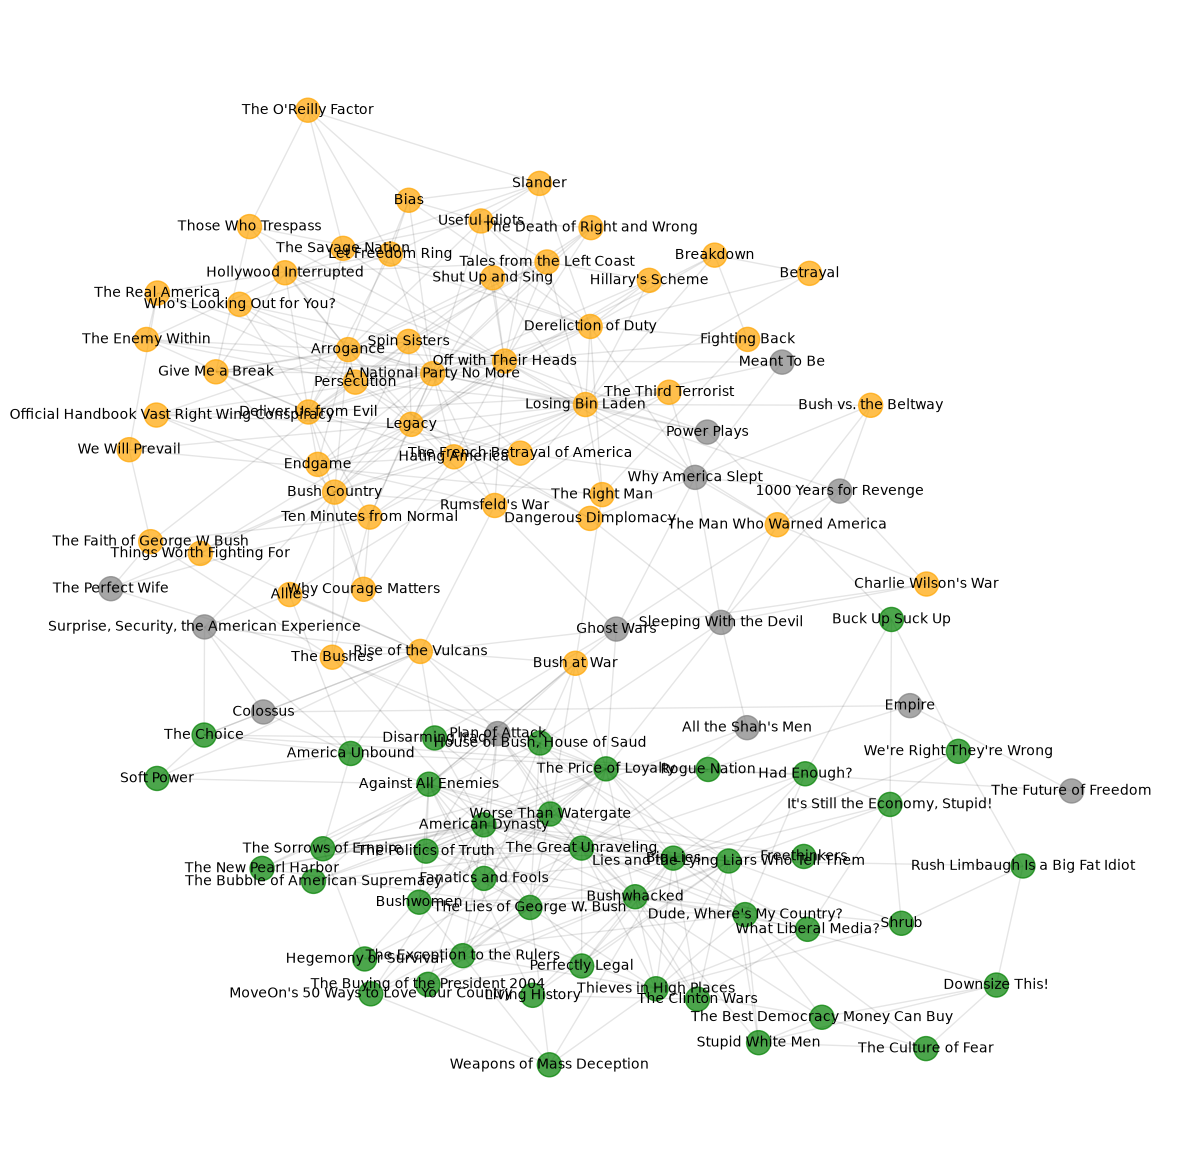

In [5]:
# import matplotlib.pyplot as plt
# import networkx as nx

# Increase figure size
plt.figure(figsize=(15, 15))

# Change layout
pos = nx.kamada_kawai_layout(gml_graph)

# Adjust node size (optional, if you have a measure like degree to scale by)
# node_sizes = [gml_graph.degree[node] * 100 for node in gml_graph.nodes()]

# Adjust font size
font_sizes = 10  # or any other size

# Define your color mapping
color_map = {'l': 'green', 'c': 'orange', 'n': 'grey'}
node_colors = [color_map[gml_graph.nodes[node]['value']] for node in gml_graph.nodes()]

# Draw nodes
nx.draw_networkx_nodes(gml_graph, pos, node_color=node_colors, alpha=0.7)

# Draw edges with transparency
nx.draw_networkx_edges(gml_graph, pos, alpha=0.1)

# Draw labels with font size
nx.draw_networkx_labels(gml_graph, pos, font_size=font_sizes)

# Remove the axes
plt.axis('off')

# Show the plot
plt.show()


/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 91.53it/s]


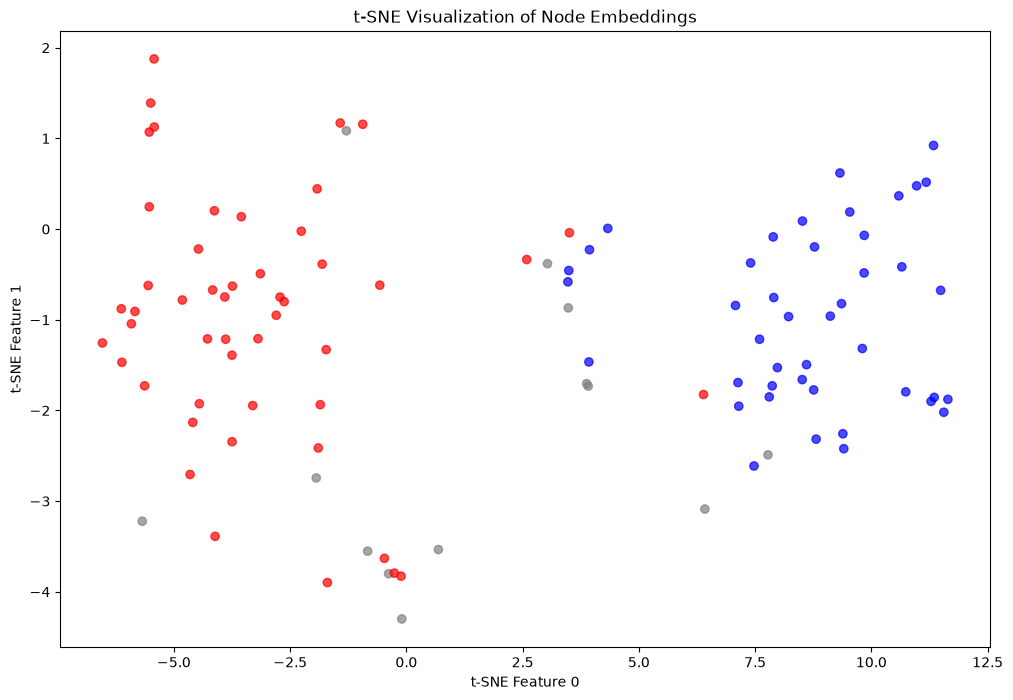

In [6]:
from node2vec import Node2Vec
import networkx as nx
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'gml_graph' is your loaded graph from the GML file
node2vec = Node2Vec(gml_graph, dimensions=64, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract node embeddings into a dictionary
embeddings = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map and the colors for each node
color_map = {'l': 'blue', 'c': 'red', 'n': 'grey'}
node_colors = [color_map[gml_graph.nodes[node]['value']] for node in gml_graph.nodes()]

# Transform the embeddings into a list of vectors for t-SNE
node_embeddings = [embeddings[str(node)] for node in gml_graph.nodes()]
node_embeddings_array = np.array(node_embeddings)  # Convert list to NumPy array

# Initialize and fit t-SNE
tsne_model = TSNE(n_components=2, learning_rate='auto', init='random')
tsne_features = tsne_model.fit_transform(node_embeddings_array)

# Plot the nodes with t-SNE embeddings and color by their 'value'
plt.figure(figsize=(12, 8))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], color=node_colors, alpha=0.7)

# Optionally, add labels for each point
#for i, node in enumerate(gml_graph.nodes()):
#    plt.annotate(node, (tsne_features[i, 0], tsne_features[i, 1]))

plt.xlabel('t-SNE Feature 0')
plt.ylabel('t-SNE Feature 1')
plt.title('t-SNE Visualization of Node Embeddings')
plt.show()


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 95.11it/s]
/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


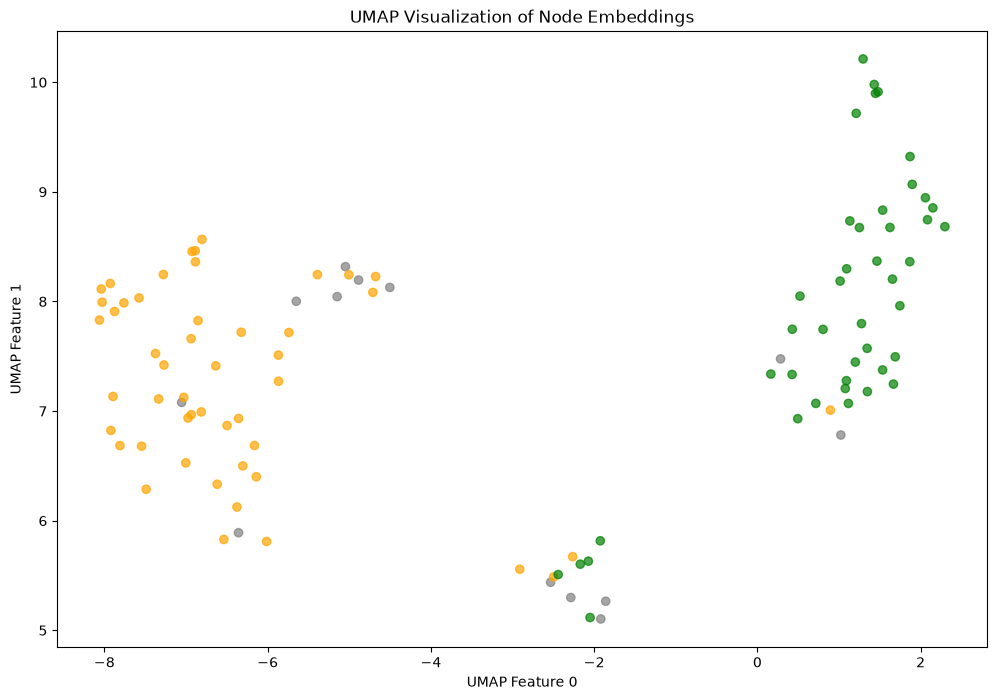

In [7]:
from node2vec import Node2Vec
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import umap


# Assuming 'gml_graph' is your loaded graph from the GML file
node2vec = Node2Vec(gml_graph, dimensions=64, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract node embeddings into a dictionary
embeddings = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map and the colors for each node
color_map = {'l': 'green', 'c': 'orange', 'n': 'grey'}
node_colors = [color_map[gml_graph.nodes[node]['value']] for node in gml_graph.nodes()]

# Transform the embeddings into a list of vectors for UMAP
node_embeddings = [embeddings[str(node)] for node in gml_graph.nodes()]
node_embeddings_array = np.array(node_embeddings)  # Convert list to NumPy array

# Initialize and fit UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = umap_model.fit_transform(node_embeddings_array)

# Plot the nodes with UMAP embeddings and color by their 'value'
plt.figure(figsize=(12, 8))
plt.scatter(umap_features[:, 0], umap_features[:, 1], color=node_colors, alpha=0.7)

# Optionally, add labels for each point
#for i, node in enumerate(gml_graph.nodes()):
#    plt.annotate(node, (umap_features[i, 0], umap_features[i, 1]))

plt.xlabel('UMAP Feature 0')
plt.ylabel('UMAP Feature 1')
plt.title('UMAP Visualization of Node Embeddings')
plt.show()


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 95.00it/s]
/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


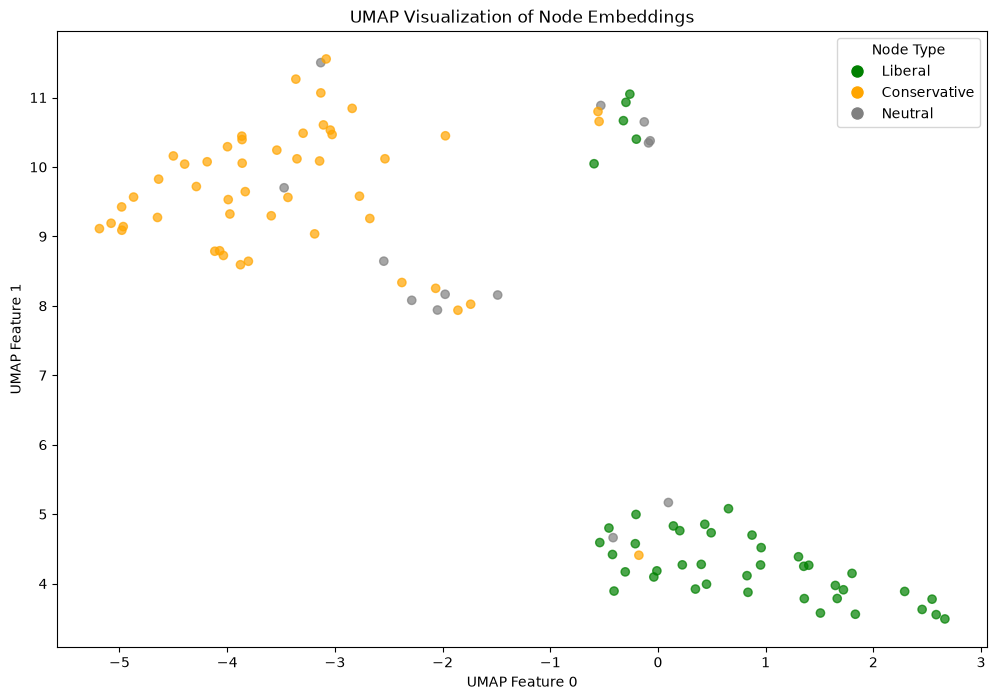

In [8]:
from node2vec import Node2Vec
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import umap

# Assuming 'gml_graph' is your loaded graph from the GML file
node2vec = Node2Vec(gml_graph, dimensions=64, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract node embeddings into a dictionary
embeddings = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map and the colors for each node
color_map = {'l': 'green', 'c': 'orange', 'n': 'grey'}
node_colors = [color_map[gml_graph.nodes[node]['value']] for node in gml_graph.nodes()]

# Transform the embeddings into a list of vectors for UMAP
node_embeddings = [embeddings[str(node)] for node in gml_graph.nodes()]
node_embeddings_array = np.array(node_embeddings)  # Convert list to NumPy array

# Initialize and fit UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = umap_model.fit_transform(node_embeddings_array)

# Plot the nodes with UMAP embeddings and color by their 'value'
plt.figure(figsize=(12, 8))

# Add scatter plot and legend
scatter = plt.scatter(umap_features[:, 0], umap_features[:, 1], color=node_colors, alpha=0.7)
legend_labels = {
    'l': 'Liberal',
    'c': 'Conservative',
    'n': 'Neutral'
}

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[key], 
                      markerfacecolor=color_map[key], markersize=10) for key in legend_labels]

plt.legend(handles=handles, title='Node Type')

# Optionally, add labels for each point
#for i, node in enumerate(gml_graph.nodes()):
#    plt.annotate(node, (umap_features[i, 0], umap_features[i, 1]))

plt.xlabel('UMAP Feature 0')
plt.ylabel('UMAP Feature 1')
plt.title('UMAP Visualization of Node Embeddings')
plt.show()


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 96.44it/s]
/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


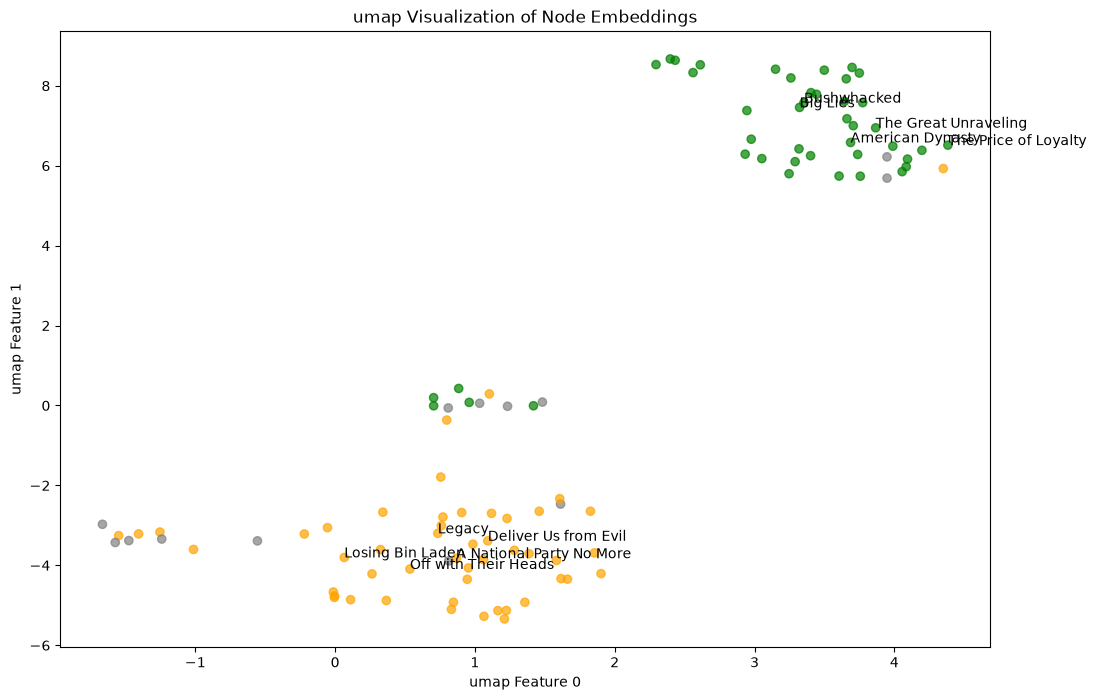

In [9]:
# Assuming 'gml_graph' is your loaded graph from the GML file
node2vec = Node2Vec(gml_graph, dimensions=64, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract node embeddings into a dictionary
embeddings = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map and the colors for each node
color_map = {'l': 'green', 'c': 'orange', 'n': 'grey'}
node_colors = [color_map[gml_graph.nodes[node]['value']] for node in gml_graph.nodes()]

# Transform the embeddings into a list of vectors for UMAP
node_embeddings = [embeddings[str(node)] for node in gml_graph.nodes()]
node_embeddings_array = np.array(node_embeddings)  # Convert list to NumPy array

# Initialize and fit UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = umap_model.fit_transform(node_embeddings_array)

##########################

# Assuming umap_features are the t-SNE 2D embeddings from your previous code
# and gml_graph is your graph object with nodes that have titles as names

# Calculate degrees of nodes and sort them
degrees = dict(gml_graph.degree())
sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)

# Decide how many nodes you want to label
num_labels = 10  # for example, you want to label the top 10 nodes by degree

# Plotting the nodes
plt.figure(figsize=(12, 8))
plt.scatter(umap_features[:, 0], umap_features[:, 1], color=node_colors, alpha=0.7)

# Adding labels to the chosen nodes
for i, node in enumerate(sorted_nodes[:num_labels]):
    # Find the index of the node to get its t-SNE coordinates
    node_index = list(gml_graph.nodes()).index(node)
    plt.annotate(node, (umap_features[node_index, 0], umap_features[node_index, 1]))

plt.xlabel('umap Feature 0')
plt.ylabel('umap Feature 1')
plt.title('umap Visualization of Node Embeddings')
plt.show()


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 99.50it/s] 
/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


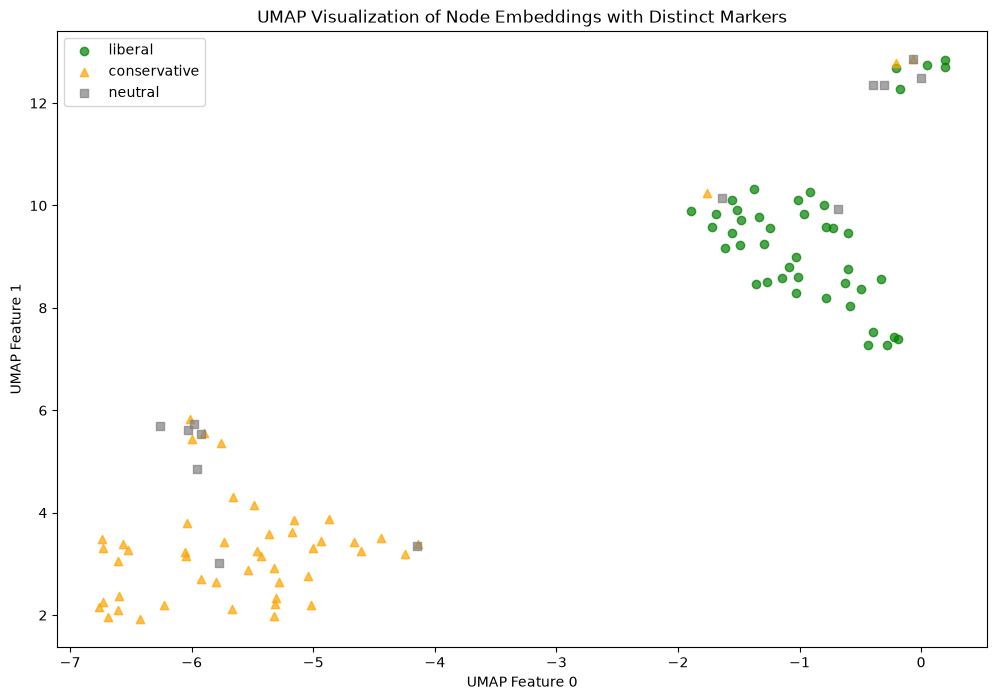

In [10]:
import matplotlib.pyplot as plt
import umap
import numpy as np

# Assuming 'gml_graph' is your loaded graph from the GML file
node2vec = Node2Vec(gml_graph, dimensions=64, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract node embeddings into a dictionary
embeddings = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map for each node class
color_map = {
    'l': 'green',
    'c': 'orange',
    'n': 'grey'
}

# Prepare a shape map for each node class
shape_map = {
    'l': 'o',  # Circle
    'c': '^',  # Triangle
    'n': 's'   # Square
}

# Map each class letter to a full label
class_labels = {
    'l': 'liberal',
    'c': 'conservative',
    'n': 'neutral'
}

# Create the list of embeddings in the same order as gml_graph.nodes()
node_embeddings = [embeddings[str(node)] for node in gml_graph.nodes()]
node_embeddings_array = np.array(node_embeddings)  # Convert list to NumPy array

# Initialize and fit UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = umap_model.fit_transform(node_embeddings_array)

# Calculate degrees of nodes and sort them (for labeling)
degrees = dict(gml_graph.degree())
sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)
num_labels = 10  # Label the top 10 nodes by degree

# --- Plotting Section ---
plt.figure(figsize=(12, 8))

# 1) Plot each class separately with its own color and marker
for class_value in color_map.keys():
    # Identify indices in 'umap_features' belonging to this class
    class_indices = [
        i for i, node in enumerate(gml_graph.nodes()) 
        if gml_graph.nodes[node]['value'] == class_value
    ]

    # Scatter plot for this class
    plt.scatter(
        umap_features[class_indices, 0],
        umap_features[class_indices, 1],
        color=color_map[class_value],
        marker=shape_map[class_value],
        alpha=0.7,
        label=class_labels[class_value]  # Use full label instead of just 'l', 'c', 'n'
    )

# 2) Label the top 'num_labels' nodes by degree
# for node in sorted_nodes[:num_labels]:
#     node_index = list(gml_graph.nodes()).index(node)
#     plt.annotate(
#         node,
#         (umap_features[node_index, 0], umap_features[node_index, 1])
#     )

# Add legend and labels
plt.legend()
plt.xlabel('UMAP Feature 0')
plt.ylabel('UMAP Feature 1')
plt.title('UMAP Visualization of Node Embeddings with Distinct Markers')
plt.show()


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 93.64it/s]
/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


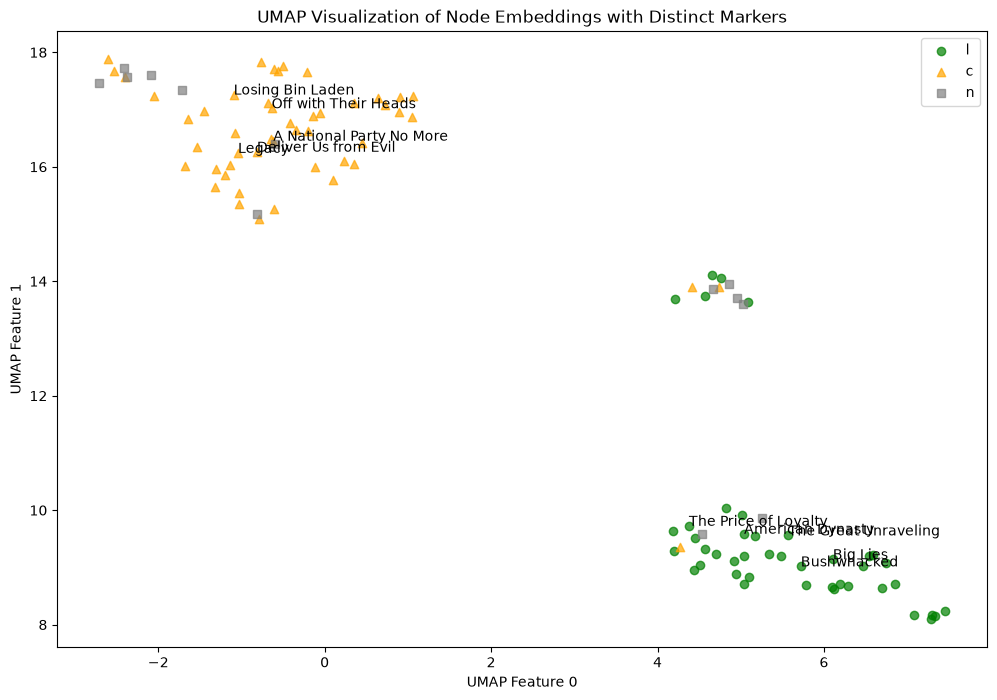

In [11]:
import matplotlib.pyplot as plt
import umap
import numpy as np

# Assuming 'gml_graph' is your loaded graph from the GML file
node2vec = Node2Vec(gml_graph, dimensions=64, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract node embeddings into a dictionary
embeddings = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map for each node class
color_map = {
    'l': 'green',
    'c': 'orange',
    'n': 'grey'
}

# Prepare a shape map for each node class
shape_map = {
    'l': 'o',  # Circle
    'c': '^',  # Triangle
    'n': 's'   # Square
}

# Create the list of embeddings in the same order as gml_graph.nodes()
node_embeddings = [embeddings[str(node)] for node in gml_graph.nodes()]
node_embeddings_array = np.array(node_embeddings)  # Convert list to NumPy array

# Initialize and fit UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = umap_model.fit_transform(node_embeddings_array)

# Calculate degrees of nodes and sort them (for labeling)
degrees = dict(gml_graph.degree())
sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)
num_labels = 10  # Label the top 10 nodes by degree

# --- Plotting Section ---
plt.figure(figsize=(12, 8))

# 1) Plot each class separately with its own color and marker
for class_value in color_map.keys():
    # Identify indices in 'umap_features' belonging to this class
    class_indices = [
        i for i, node in enumerate(gml_graph.nodes()) 
        if gml_graph.nodes[node]['value'] == class_value
    ]

    # Scatter plot for this class
    plt.scatter(
        umap_features[class_indices, 0],
        umap_features[class_indices, 1],
        color=color_map[class_value],
        marker=shape_map[class_value],
        alpha=0.7,
        label=f"{class_value}"
    )

# 2) Label the top 'num_labels' nodes by degree
for node in sorted_nodes[:num_labels]:
    node_index = list(gml_graph.nodes()).index(node)
    plt.annotate(
        node,
        (umap_features[node_index, 0], umap_features[node_index, 1])
    )

# Add legend and labels
plt.legend()
plt.xlabel('UMAP Feature 0')
plt.ylabel('UMAP Feature 1')
plt.title('UMAP Visualization of Node Embeddings with Distinct Markers')
plt.show()


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 96.49it/s]


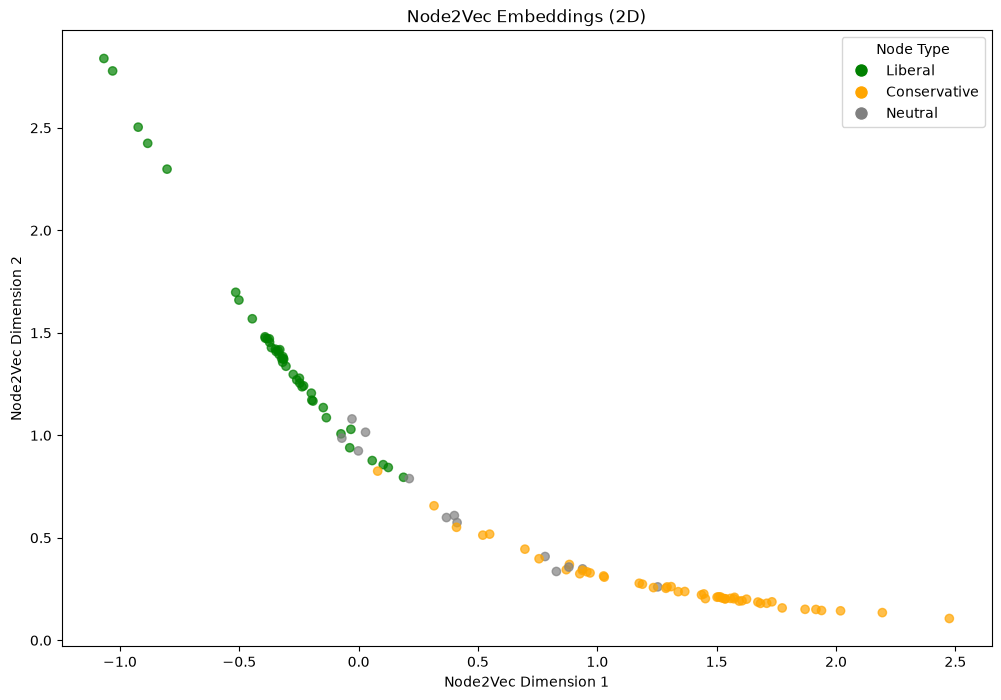

In [12]:
# from node2vec import Node2Vec
# import networkx as nx
# import matplotlib.pyplot as plt

# Assuming 'gml_graph' is your loaded graph from the GML file
# Set dimensions to 2 for direct plotting
node2vec = Node2Vec(gml_graph, dimensions=2, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract 2D embeddings into a dictionary
embeddings_2d = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map and the colors for each node based on their 'value'
color_map = {'l': 'green', 'c': 'orange', 'n': 'grey'}
node_colors = [color_map[gml_graph.nodes[node]['value']] for node in gml_graph.nodes()]

# Prepare the 2D points for plotting
points = np.array([embeddings_2d[node] for node in gml_graph.nodes()])

# Plot the nodes with their 2D embeddings
plt.figure(figsize=(12, 8))
plt.scatter(points[:, 0], points[:, 1], color=node_colors, alpha=0.7)

# Optionally, you can label the points
# for i, node in enumerate(gml_graph.nodes()):
#     plt.annotate(node, (points[i, 0], points[i, 1]), fontsize=9)

legend_labels = {
    'l': 'Liberal',
    'c': 'Conservative',
    'n': 'Neutral'
}

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[key], 
                      markerfacecolor=color_map[key], markersize=10) for key in legend_labels]

plt.legend(handles=handles, title='Node Type')



plt.xlabel('Node2Vec Dimension 1')
plt.ylabel('Node2Vec Dimension 2')
plt.title('Node2Vec Embeddings (2D)')
plt.show()


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 94.21it/s]


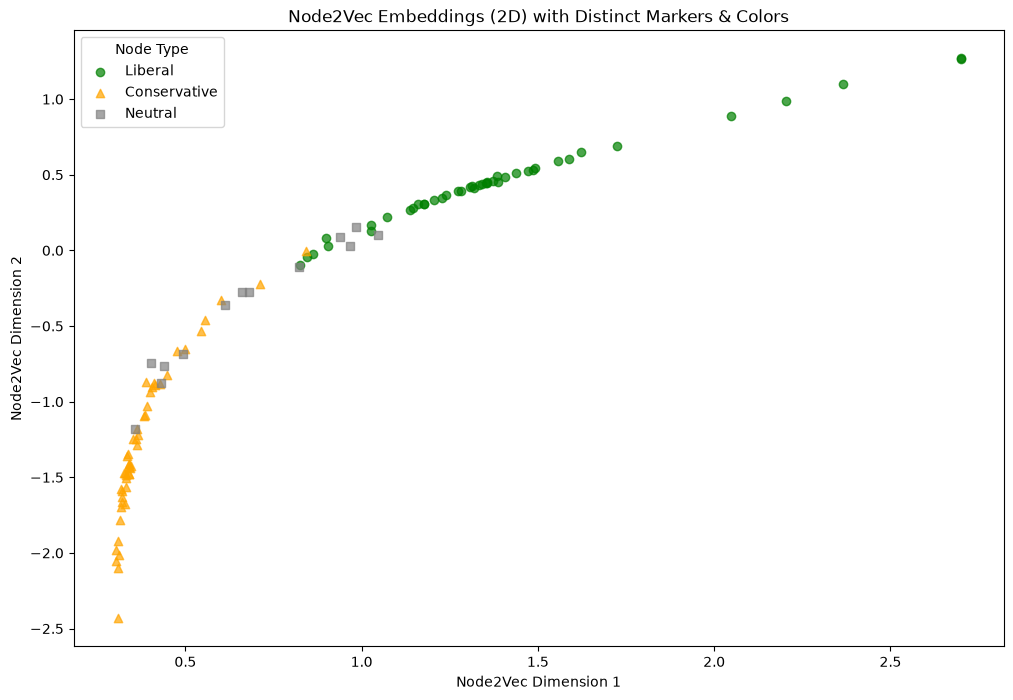

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'gml_graph' is your loaded graph from the GML file

# Set dimensions=2 for direct 2D plotting
node2vec = Node2Vec(gml_graph, dimensions=2, walk_length=30, num_walks=200, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extract 2D embeddings into a dictionary
embeddings_2d = {str(node): model.wv[str(node)] for node in gml_graph.nodes()}

# Prepare a color map
color_map = {
    'l': 'green',
    'c': 'orange',
    'n': 'grey'
}

# Prepare a shape map
shape_map = {
    'l': 'o',  # Circle
    'c': '^',  # Triangle
    'n': 's'   # Square
}

# Map each class letter to a full legend label
legend_labels = {
    'l': 'Liberal',
    'c': 'Conservative',
    'n': 'Neutral'
}

# Create a list of nodes to maintain a fixed order
node_list = list(gml_graph.nodes())

# Convert the embeddings to a NumPy array (in the same order as node_list)
points = np.array([embeddings_2d[node] for node in node_list])

# --- Plotting Section ---
plt.figure(figsize=(12, 8))

# Plot each class separately with its own color and marker
for class_value in color_map.keys():
    # Indices of nodes belonging to this class
    class_indices = [
        i for i, node in enumerate(node_list)
        if gml_graph.nodes[node]['value'] == class_value
    ]
    
    # Scatter plot for this class
    plt.scatter(
        points[class_indices, 0],  # x-coordinates
        points[class_indices, 1],  # y-coordinates
        color=color_map[class_value],
        marker=shape_map[class_value],
        alpha=0.7,
        label=legend_labels[class_value]
    )

# Optionally label specific nodes
# for i, node in enumerate(node_list):
#     plt.annotate(node, (points[i, 0], points[i, 1]), fontsize=9)

# Create a legend from the scatter calls above
plt.legend(title='Node Type')

# Axes labels and title
plt.xlabel('Node2Vec Dimension 1')
plt.ylabel('Node2Vec Dimension 2')
plt.title('Node2Vec Embeddings (2D) with Distinct Markers & Colors')
plt.show()


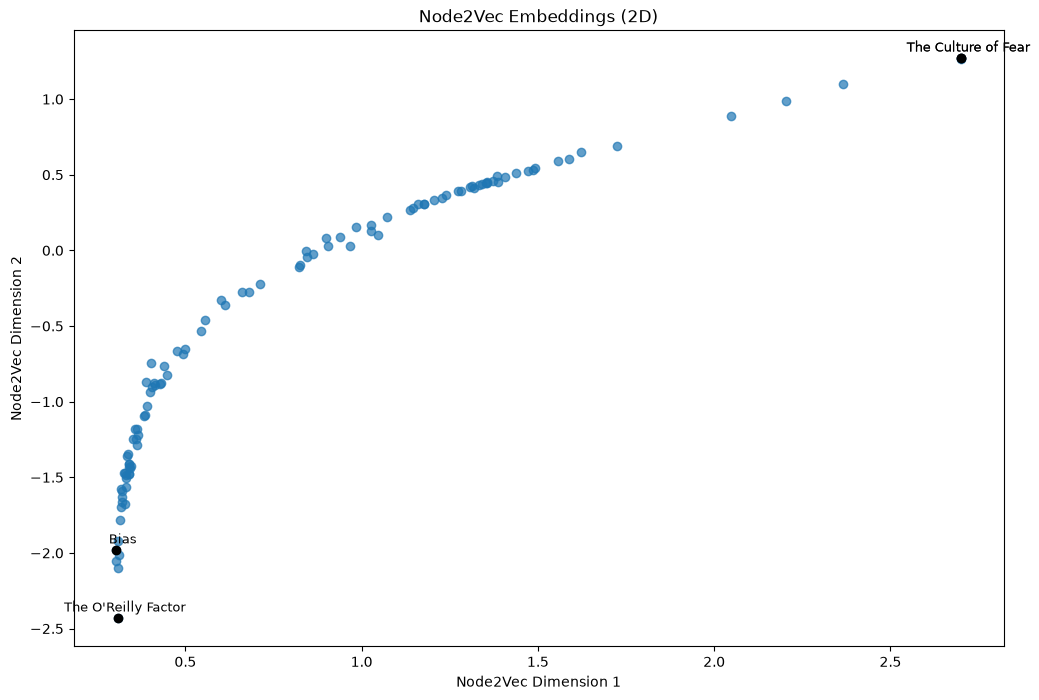

In [14]:
# import numpy as np
# import matplotlib.pyplot as plt

# Let's assume `points` is the numpy array with your Node2Vec 2D points
# and `gml_graph` is your original graph with node labels.

# Identify extreme points
extreme_indices = {
    'leftmost': np.argmin(points[:, 0]),
    'rightmost': np.argmax(points[:, 0]),
    'topmost': np.argmax(points[:, 1]),
    'bottommost': np.argmin(points[:, 1])
}

# Create a figure for plotting
plt.figure(figsize=(12, 8))

# Scatter plot of all points
plt.scatter(points[:, 0], points[:, 1], alpha=0.7)

# Get the node labels from your graph
node_labels = list(gml_graph.nodes())

# Annotate the extreme points
for key, index in extreme_indices.items():
    node_label = node_labels[index]
    x, y = points[index]
    plt.scatter(x, y, color='black')  # Mark the extreme point
    plt.annotate(node_label, (x, y), textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

plt.xlabel('Node2Vec Dimension 1')
plt.ylabel('Node2Vec Dimension 2')
plt.title('Node2Vec Embeddings (2D)')
plt.show()


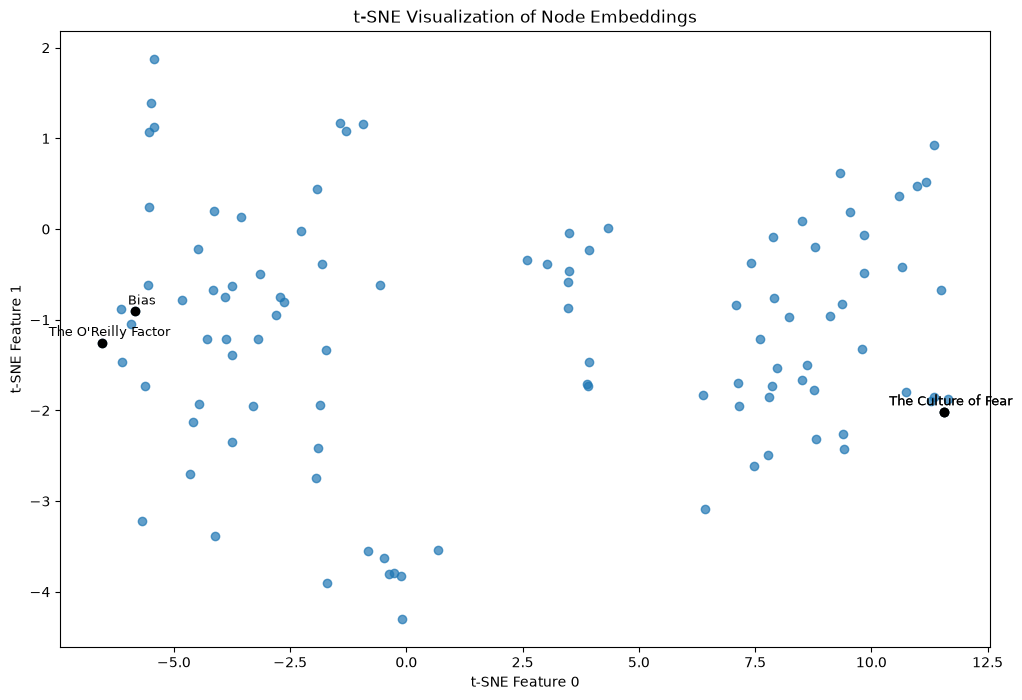

In [15]:
# import numpy as np
# import matplotlib.pyplot as plt

# Assuming `points` contains your Node2Vec 2D points
# and `tsne_features` contains your t-SNE 2D points
# and they are aligned with the nodes in `gml_graph`

# Identify extreme points in Node2Vec space
extreme_indices = {
    'leftmost': np.argmin(points[:, 0]),
    'rightmost': np.argmax(points[:, 0]),
    'topmost': np.argmax(points[:, 1]),
    'bottommost': np.argmin(points[:, 1])
}

# Assuming `tsne_features` is already computed and ready to be plotted
plt.figure(figsize=(12, 8))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], alpha=0.7)

# Get the node labels from your graph
node_labels = list(gml_graph.nodes())

# Annotate the extreme points on the t-SNE plot
for position, index in extreme_indices.items():
    label = node_labels[index]  # Label of the extreme point
    x, y = tsne_features[index]  # Coordinates of the extreme point in t-SNE space
    plt.scatter(x, y, color='black')  # Highlight the extreme point
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

plt.xlabel('t-SNE Feature 0')
plt.ylabel('t-SNE Feature 1')
plt.title('t-SNE Visualization of Node Embeddings')
plt.show()


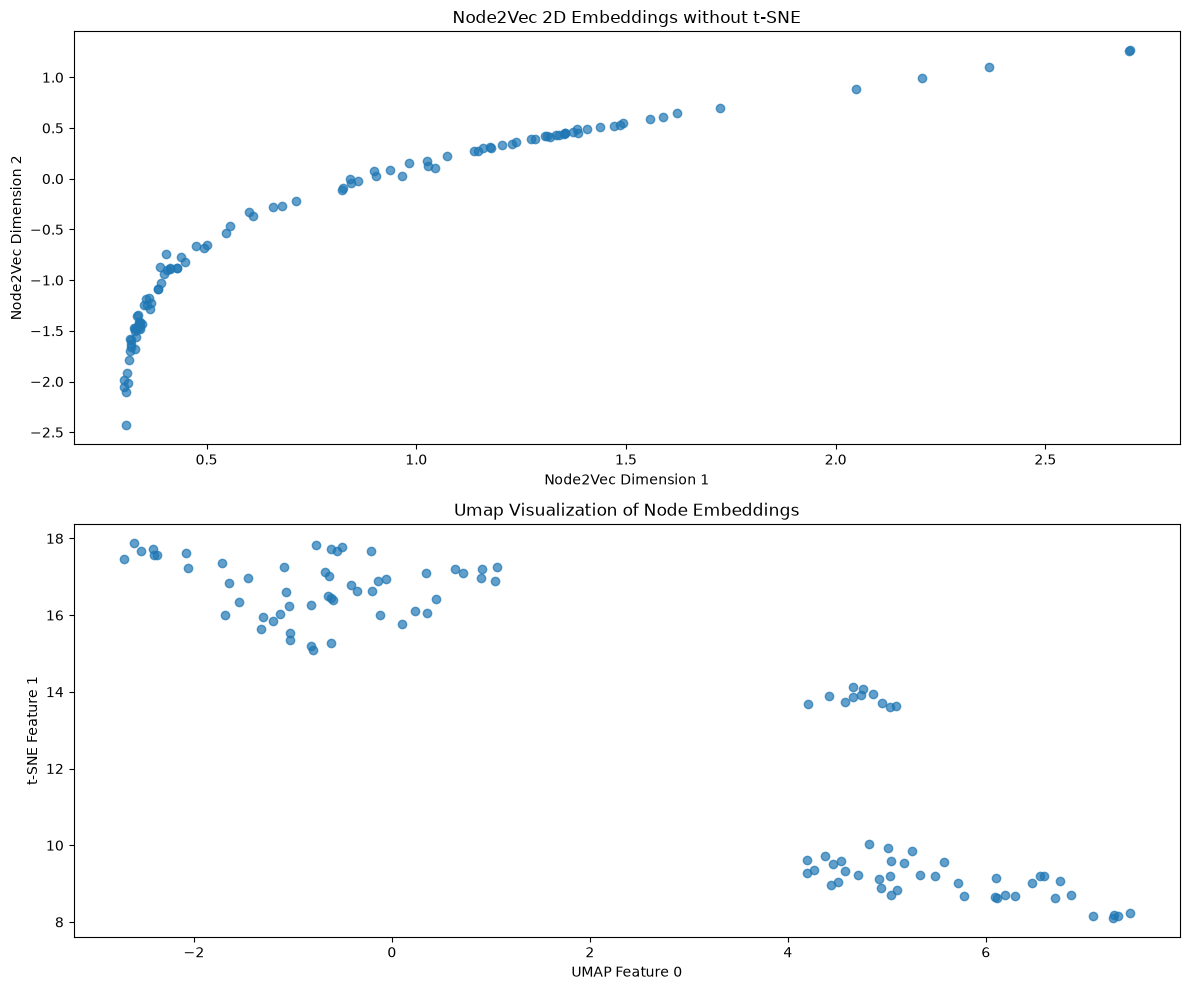

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `points` contains your Node2Vec 2D points
# `tsne_features` contains your t-SNE 2D points
# and they are aligned with the nodes in `gml_graph`

# Identify extreme points in Node2Vec space
extreme_indices = {
    'leftmost': np.argmin(points[:, 0]),
    'rightmost': np.argmax(points[:, 0]),
    'topmost': np.argmax(points[:, 1]),
    'bottommost': np.argmin(points[:, 1])
}

# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10))  # 2 rows, 1 column

# Plot t-SNE Embeddings in the second subplot
axs[1].scatter(umap_features[:, 0], umap_features[:, 1], alpha=0.7)
# for position, index in extreme_indices.items():
#     label = node_labels[index]
#     x, y = umap_features[index]
#     axs[1].scatter(x, y, color='black')
#     axs[1].annotate(label, (x, y), textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)
axs[1].set_title('Umap Visualization of Node Embeddings')
axs[1].set_xlabel('UMAP Feature 0')
axs[1].set_ylabel('t-SNE Feature 1')

# Plot Node2Vec Embeddings in the first subplot
axs[0].scatter(points[:, 0], points[:, 1], alpha=0.7)
# for position, index in extreme_indices.items():
#     label = node_labels[index]
#     x, y = points[index]
#     axs[0].scatter(x, y, color='black')
#     axs[0].annotate(label, (x, y), textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)
axs[0].set_title('Node2Vec 2D Embeddings without t-SNE')
axs[0].set_xlabel('Node2Vec Dimension 1')
axs[0].set_ylabel('Node2Vec Dimension 2')



# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [17]:
node_embedding = model.wv['Losing Bin Laden']  
print(node_embedding)  

[ 0.35892823 -1.246693  ]


In [18]:
type(node_embedding)

numpy.ndarray

In [19]:
# Install the required libraries for GNNs if you haven't already
!pip install torch torchvision
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 6.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 6.4 MB/s eta 0:00:00:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 11.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 17.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 7.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 11.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 7.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 7.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━ 133.7/214.1 MB 14.4 MB/s eta 0:00:06
ERROR: Exception:
Traceback (most recent call last):
  File "/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/C

In [23]:
!pip install torch

  Using cached torch-2.14.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached filelock-4.0.4-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached cuda_toolkit-13.0.3.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached cuda_bindings-13.4.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached nvidia_cudnn_cu13-9.24.0.43-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.30.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (978 bytes)
  Using cached nvidia_cubl

In [24]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
# import torch_geometric
# print(torch_geometric.__version__)


/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [25]:


class SimpleGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super(SimpleGNN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):
        # First Graph Convolutional layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        
        # Second Graph Convolutional layer
        x = self.conv2(x, edge_index)
        
        # return x
        return x, F.log_softmax(x, dim=1)


In [26]:
from torch_geometric.utils.convert import from_networkx
import torch.nn as nn

# Convert NetworkX graph to a PyTorch Geometric Data object
data = from_networkx(gml_graph)



# Initialize node features with Xavier initialization
num_features = 64  # Set the desired number of features
data.x = torch.empty((data.num_nodes, num_features), dtype=torch.float)  # Create an empty tensor
nn.init.xavier_uniform_(data.x)  # Apply Xavier initialization

# Instantiate the model
model = SimpleGNN(num_features=data.x.shape[1], hidden_channels=64)

# Switch the model to evaluation mode
model.eval()

# Perform a forward pass with no gradient computation
with torch.no_grad():
    gnn_embeddings = model(data.x, data.edge_index)


In [27]:

gnn_embeddings

(tensor([[ 0.0080,  0.0262,  0.0126,  ..., -0.0212,  0.0157,  0.0003],
         [ 0.0050,  0.0220,  0.0133,  ..., -0.0185,  0.0117, -0.0016],
         [ 0.0122,  0.0265,  0.0077,  ..., -0.0185,  0.0118,  0.0032],
         ...,
         [ 0.0002,  0.0197, -0.0173,  ...,  0.0171,  0.0211, -0.0059],
         [-0.0074,  0.0037, -0.0035,  ..., -0.0295,  0.0256,  0.0178],
         [-0.0076,  0.0085, -0.0037,  ..., -0.0213,  0.0212,  0.0182]]),
 tensor([[-4.1516, -4.1334, -4.1471,  ..., -4.1808, -4.1440, -4.1593],
         [-4.1542, -4.1371, -4.1459,  ..., -4.1777, -4.1474, -4.1608],
         [-4.1477, -4.1334, -4.1522,  ..., -4.1784, -4.1481, -4.1567],
         ...,
         [-4.1609, -4.1414, -4.1784,  ..., -4.1440, -4.1400, -4.1671],
         [-4.1714, -4.1602, -4.1674,  ..., -4.1934, -4.1384, -4.1462],
         [-4.1724, -4.1563, -4.1685,  ..., -4.1861, -4.1436, -4.1466]]))

/mnt/01DCB9B1454D8350/DATA/Project/Python_Project/CD3_Project/GNN_AI_C-3/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_33491/3911076130.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_features[:, 0], umap_features[:, 1], c=node_colors, cmap='viridis', s=15)


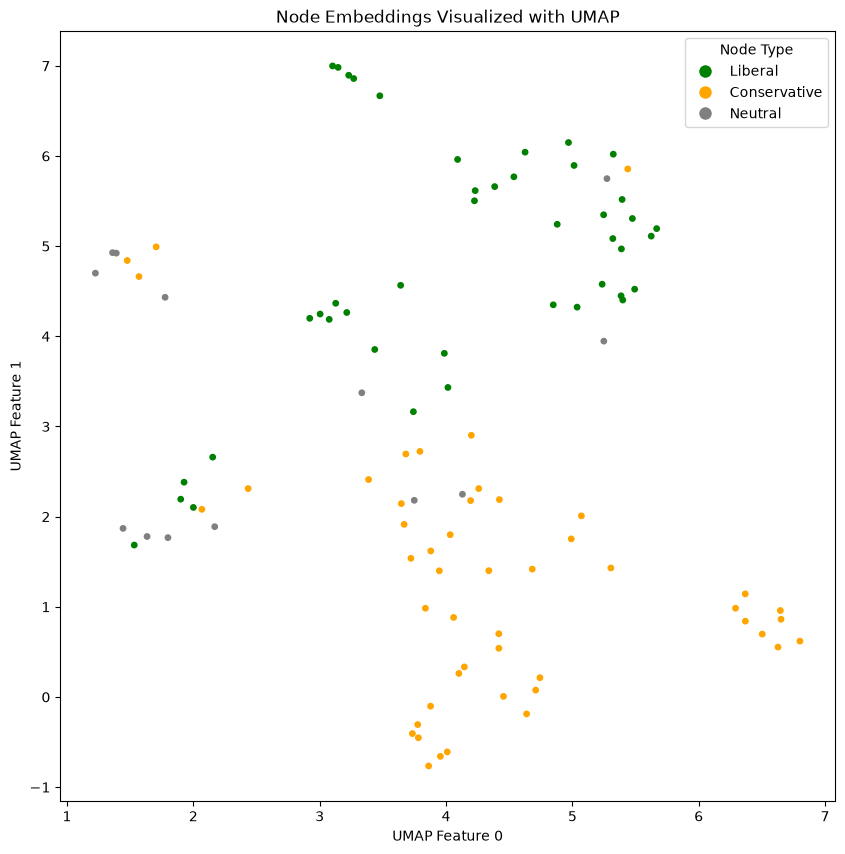

In [28]:
from sklearn.manifold import TSNE

# Convert to numpy for t-SNE
gnn_embeddings_np = gnn_embeddings[0].detach().cpu().numpy() # if using GPU

# Initialize and fit UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = umap_model.fit_transform(gnn_embeddings_np)

# Plot the result of t-SNE
plt.figure(figsize=(10, 10))
plt.scatter(umap_features[:, 0], umap_features[:, 1], c=node_colors, cmap='viridis', s=15)
plt.title('Node Embeddings Visualized with UMAP')
plt.xlabel('UMAP Feature 0')
plt.ylabel('UMAP Feature 1')


legend_labels = {
    'l': 'Liberal',
    'c': 'Conservative',
    'n': 'Neutral'
}

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[key], 
                      markerfacecolor=color_map[key], markersize=10) for key in legend_labels]

plt.legend(handles=handles, title='Node Type')

plt.show()


Section 2.3 Using Node Embeddings

In [29]:
import numpy as np
import random

# Extract labels and handle neutral values
labels = []
for node, data in gml_graph.nodes(data=True):
    if data['value'] == 'c':
        labels.append('right')
    elif data['value'] == 'l':
        labels.append('left')
    else:  # Handle neutral and missing values
        labels.append('neutral')

labels = np.array(labels)

# Random seed for reproducibility
random.seed(52)

# Indices of all nodes
indices = list(range(len(labels)))

# Percentage of data to keep as labelled
labelled_percentage = 0.2  # e.g., 10% as labelled

# Select a subset of indices to remain labelled
labelled_indices = random.sample(indices, int(labelled_percentage * len(labels)))

# Initialize masks for labelled and unlabelled data
labelled_mask = np.zeros(len(labels), dtype=bool)
unlabelled_mask = np.ones(len(labels), dtype=bool)

# Update masks
labelled_mask[labelled_indices] = True
unlabelled_mask[labelled_indices] = False

# Use masks to split the dataset
labelled_labels = labels[labelled_mask]
unlabelled_labels = labels[unlabelled_mask]  # You won't use these labels during training

label_mapping = {'left': 0, 'right': 1, 'neutral': 2}
numeric_labels = np.array([label_mapping[label] for label in labels])



In [30]:
labelled_labels


array(['neutral', 'right', 'neutral', 'neutral', 'right', 'right',
       'right', 'right', 'left', 'right', 'right', 'right', 'right',
       'right', 'right', 'left', 'left', 'neutral', 'left', 'left',
       'left'], dtype='<U7')

In [31]:
labels

array(['neutral', 'right', 'right', 'right', 'neutral', 'right',
       'neutral', 'neutral', 'right', 'right', 'right', 'right', 'right',
       'right', 'right', 'right', 'right', 'right', 'neutral', 'right',
       'right', 'right', 'right', 'right', 'right', 'right', 'right',
       'right', 'neutral', 'right', 'left', 'left', 'right', 'right',
       'right', 'right', 'right', 'right', 'right', 'right', 'right',
       'right', 'right', 'right', 'right', 'right', 'neutral', 'right',
       'neutral', 'right', 'right', 'neutral', 'right', 'right', 'right',
       'right', 'right', 'right', 'right', 'left', 'left', 'left', 'left',
       'left', 'left', 'left', 'left', 'left', 'left', 'neutral', 'left',
       'left', 'left', 'left', 'left', 'left', 'neutral', 'right', 'left',
       'left', 'left', 'left', 'left', 'left', 'left', 'left', 'left',
       'left', 'left', 'left', 'left', 'left', 'left', 'left', 'left',
       'left', 'left', 'left', 'left', 'left', 'left', 'left', 'lef

In [32]:
label_mapping = {'left': 0, 'right': 1, 'neutral': 2}
numeric_labels = np.array([label_mapping[label] for label in labels])


# For GNN embeddings
X_train_gnn, y_train_gnn = gnn_embeddings[0][labelled_mask], numeric_labels[labelled_mask]

# For N2V embeddings
# Ensure node2vec embeddings are in the same order as labels
X_n2v = np.array([embeddings[str(node)] for node in gml_graph.nodes()])
X_train_n2v, y_train_n2v = X_n2v[labelled_mask], numeric_labels[labelled_mask]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Classifier for GNN embeddings
clf_gnn = RandomForestClassifier()
clf_gnn.fit(X_train_gnn, y_train_gnn)

# Classifier for N2V embeddings
clf_n2v = RandomForestClassifier()
clf_n2v.fit(X_train_n2v, y_train_n2v)

from sklearn.metrics import f1_score

# Predictions with GNN embeddings
y_pred_gnn = clf_gnn.predict(gnn_embeddings[0][unlabelled_mask])
# Evaluate GNN classifier
gnn_accuracy = accuracy_score(numeric_labels[unlabelled_mask], y_pred_gnn)
gnn_f1_score = f1_score(numeric_labels[unlabelled_mask], y_pred_gnn, average='weighted')

# Predictions with N2V embeddings
y_pred_n2v = clf_n2v.predict(X_n2v[unlabelled_mask])
# Evaluate N2V classifier
n2v_accuracy = accuracy_score(numeric_labels[unlabelled_mask], y_pred_n2v)
n2v_f1_score = f1_score(numeric_labels[unlabelled_mask], y_pred_n2v, average='weighted')

print(f"GNN Accuracy: {gnn_accuracy:.4f}")
print(f"GNN F1 Score: {gnn_f1_score:.4f}")
print(f"N2V Accuracy: {n2v_accuracy:.4f}")
print(f"N2V F1 Score: {n2v_f1_score:.4f}")


GNN Accuracy: 0.6429
GNN F1 Score: 0.6069
N2V Accuracy: 0.8810
N2V F1 Score: 0.8621


In [33]:
from sklearn.metrics import log_loss

def adjust_proba(y_pred_proba, all_classes):
    # Check if predicted probabilities cover all classes
    if y_pred_proba.shape[1] != len(all_classes):
        # Create a new array with a column for each class
        adjusted_proba = np.zeros((y_pred_proba.shape[0], len(all_classes)))
        # Fill in the probabilities for the classes that the classifier provided
        for idx, cls in enumerate(clf_gnn.classes_):  # Assuming clf_gnn.classes_ is in the order of the output probabilities
            class_idx = np.where(all_classes == cls)[0][0]
            adjusted_proba[:, class_idx] = y_pred_proba[:, idx]
        return adjusted_proba
    else:
        return y_pred_proba

all_classes = np.array([0, 1, 2])  # Assuming these are the numeric labels for 'left', 'right', 'neutral'
y_pred_proba_n2v = clf_n2v.predict_proba(X_n2v[unlabelled_mask])
#y_pred_proba_gnn = clf_gnn.predict_proba(gnn_embeddings[0][unlabelled_mask])
y_pred_proba_gnn = clf_gnn.predict_proba(gnn_embeddings[0])


# Adjust the predicted probabilities
y_pred_proba_gnn_adjusted = adjust_proba(y_pred_proba_gnn, all_classes)
y_pred_proba_n2v_adjusted = adjust_proba(y_pred_proba_n2v, all_classes)


from sklearn.metrics import log_loss

# Compute log loss using the adjusted probabilities
log_loss_gnn = log_loss(numeric_labels[unlabelled_mask], y_pred_proba_gnn_adjusted[unlabelled_mask], labels=all_classes)
log_loss_n2v = log_loss(numeric_labels[unlabelled_mask], y_pred_proba_n2v_adjusted, labels=all_classes)

print(f"GNN Log Loss: {log_loss_gnn:.4f}")
print(f"N2V Log Loss: {log_loss_n2v:.4f}")



GNN Log Loss: 0.7049
N2V Log Loss: 0.4982


In [34]:
numeric_labels[unlabelled_mask]

array([1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2])

In [35]:
y_pred_proba_gnn

array([[0.08, 0.2 , 0.72],
       [0.15, 0.72, 0.13],
       [0.28, 0.28, 0.44],
       [0.08, 0.66, 0.26],
       [0.13, 0.06, 0.81],
       [0.15, 0.24, 0.61],
       [0.05, 0.1 , 0.85],
       [0.4 , 0.32, 0.28],
       [0.03, 0.93, 0.04],
       [0.05, 0.88, 0.07],
       [0.16, 0.69, 0.15],
       [0.11, 0.76, 0.13],
       [0.01, 0.85, 0.14],
       [0.07, 0.88, 0.05],
       [0.24, 0.66, 0.1 ],
       [0.23, 0.64, 0.13],
       [0.24, 0.65, 0.11],
       [0.06, 0.91, 0.03],
       [0.16, 0.72, 0.12],
       [0.43, 0.5 , 0.07],
       [0.01, 0.97, 0.02],
       [0.23, 0.71, 0.06],
       [0.23, 0.62, 0.15],
       [0.02, 0.92, 0.06],
       [0.13, 0.82, 0.05],
       [0.32, 0.53, 0.15],
       [0.1 , 0.86, 0.04],
       [0.04, 0.91, 0.05],
       [0.37, 0.45, 0.18],
       [0.28, 0.58, 0.14],
       [0.76, 0.19, 0.05],
       [0.41, 0.49, 0.1 ],
       [0.12, 0.82, 0.06],
       [0.06, 0.85, 0.09],
       [0.14, 0.83, 0.03],
       [0.1 , 0.84, 0.06],
       [0.14, 0.84, 0.02],
 

In [36]:
X_train_n2v

array([[ 0.28765708, -0.27916294,  0.01651141, ..., -0.42808113,
        -0.18084621,  0.31099516],
       [ 0.2499504 , -0.37962756,  0.19248506, ..., -0.2863074 ,
        -0.13993585,  0.01234187],
       [ 0.17500845, -0.4248869 ,  0.02998233, ..., -0.44264588,
        -0.08089036,  0.06841625],
       ...,
       [-0.10856908, -0.02232072, -0.05199714, ..., -0.22155957,
         0.2611065 ,  0.14623857],
       [-0.1320902 , -0.02107203, -0.0662148 , ..., -0.17357643,
         0.2126119 ,  0.2641681 ],
       [-0.13291183, -0.33207977,  0.05434333, ..., -0.03651773,
         0.4075322 ,  0.6116837 ]], dtype=float32)

In [37]:
# Convert NetworkX graph to a PyTorch Geometric Data object
data = from_networkx(gml_graph)

# Prepare the node features (using Node2Vec embeddings)
# node_features = torch.tensor(node_embeddings, dtype=torch.float)

# Add node features to data
# data.x = node_features

# Note: If you have no initial node features, you could alternatively initialize them randomly
data.x = torch.randn((data.num_nodes, 64), dtype=torch.float)

train_labels = torch.tensor(numeric_labels, dtype=torch.long)[labelled_mask]

# Assuming 'labelled_mask' is a boolean array indicating which nodes are labelled
data.train_mask = torch.tensor(labelled_mask, dtype=torch.bool)

In [38]:
# Define the number of input features and output classes
num_features = data.num_features  # Assuming data.x contains the node features
num_classes = 3  # Assuming you have 3 classes in your classification task

# Initialize the model
class SimpleGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super(SimpleGNN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):
        # First Graph Convolutional layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        
        # Second Graph Convolutional layer
        x = self.conv2(x, edge_index)
        
        return x, F.log_softmax(x, dim=1)

In [39]:
#  Version with 4 GCN layers
class SimpleGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super(SimpleGNN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)  # Add another GCN layer
        self.conv4 = GCNConv(hidden_channels, hidden_channels)  # Add another GCN layer

    def forward(self, x, edge_index):
        # First Graph Convolutional layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        
        # Second Graph Convolutional layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        
        # Third Graph Convolutional layer
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        
        # Fourth Graph Convolutional layer
        x = self.conv4(x, edge_index)
        
        return x, F.log_softmax(x, dim=1)


In [40]:
model = SimpleGNN(num_features=data.x.shape[1], hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [42]:
class SimpleGNN_2(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(SimpleGNN_2, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# uncomment the line below to use the 2-layer GNN model with a single output layer for classification
model = SimpleGNN_2(num_features=num_features, num_classes=num_classes)


In [43]:

# Convert NetworkX graph to a PyTorch Geometric Data object
data = from_networkx(gml_graph)

# Prepare the node features (using Node2Vec embeddings)
# node_features = torch.tensor(node_embeddings, dtype=torch.float)

# Add node features to data
# data.x = node_features

# Note: If you have no initial node features, you could alternatively initialize them randomly
data.x = torch.randn((data.num_nodes, 64), dtype=torch.float)

In [44]:
train_labels = torch.tensor(numeric_labels, dtype=torch.long)[labelled_mask]


In [47]:

# Convert NetworkX graph to a PyTorch Geometric Data object
data = from_networkx(gml_graph)

# Prepare the node features (using Node2Vec embeddings)
# node_features = torch.tensor(node_embeddings, dtype=torch.float)

# Add node features to data
# data.x = node_features

# Note: If you have no initial node features, you could alternatively initialize them randomly
data.x = torch.randn((data.num_nodes, 64), dtype=torch.float)

train_labels = torch.tensor(numeric_labels, dtype=torch.long)[labelled_mask]

# Assuming 'labelled_mask' is a boolean array indicating which nodes are labelled
data.train_mask = torch.tensor(labelled_mask, dtype=torch.bool)

loss_fn = torch.nn.NLLLoss()

for epoch in range(200):  # Number of epochs
    optimizer.zero_grad()
    # Pass both node features and edge_index to the model
    model_out = model(data.x, data.edge_index)

    # Handle models that return (embeddings, logits) or just logits
    if isinstance(model_out, (tuple, list)):
        out = model_out[-1]
    else:
        out = model_out

    # Apply the training mask to select only the outputs for the labelled nodes
    out_masked = out[data.train_mask]

    # Compute the loss using only the labelled nodes
    loss = loss_fn(out_masked, train_labels)
    loss.backward()
    optimizer.step()
    

    if epoch % 10 == 0:  # Print loss every 10 epochs
        print(f'Epoch {epoch}, Log Loss: {loss.item()}')


Epoch 0, Log Loss: 1.176405668258667
Epoch 10, Log Loss: 1.1770745515823364
Epoch 20, Log Loss: 1.1545820236206055
Epoch 30, Log Loss: 1.1281934976577759
Epoch 40, Log Loss: 1.1464797258377075
Epoch 50, Log Loss: 1.1253678798675537
Epoch 60, Log Loss: 1.0718421936035156
Epoch 70, Log Loss: 1.1890932321548462
Epoch 80, Log Loss: 1.1729536056518555
Epoch 90, Log Loss: 1.1128723621368408
Epoch 100, Log Loss: 1.144844889640808
Epoch 110, Log Loss: 1.0951731204986572
Epoch 120, Log Loss: 1.14385187625885
Epoch 130, Log Loss: 1.1330646276474
Epoch 140, Log Loss: 1.094429612159729
Epoch 150, Log Loss: 1.131026268005371
Epoch 160, Log Loss: 1.1484671831130981
Epoch 170, Log Loss: 1.143688440322876
Epoch 180, Log Loss: 1.1527079343795776
Epoch 190, Log Loss: 1.1165201663970947


In [48]:
# Get model output (handle models that return tuples like (embeddings, logits))
model_out = model(data.x, data.edge_index)
if isinstance(model_out, (tuple, list)):
	out_all = model_out[-1]  # assume last element contains logits/log-probs
else:
	out_all = model_out

# Ensure out_all is a torch tensor (and on the right device)
if not isinstance(out_all, torch.Tensor):
	out_all = torch.tensor(out_all, dtype=torch.float)

# Convert the numpy boolean mask to a torch bool tensor on the same device
mask = torch.tensor(labelled_mask, dtype=torch.bool, device=out_all.device)

# Select only the labeled nodes' outputs
out_masked = out_all[mask]

# Move training labels to the same device
train_labels = train_labels.to(out_masked.device)

# Compute the loss using only the labeled nodes
loss = loss_fn(out_masked, train_labels)

print(f'Training Log Loss: {loss.item()}')


Training Log Loss: 1.1879945993423462


In [49]:
# Pass the entire dataset through the model to obtain predicted probabilities for all nodes
with torch.no_grad():
    out = model(data.x, data.edge_index)

# Adjust the predicted probabilities
y_pred_proba_gnn_adjusted = adjust_proba(y_pred_proba_gnn, all_classes)

# Select only the predicted probabilities for the unlabelled nodes
y_pred_proba_gnn_unlabelled = y_pred_proba_gnn_adjusted[unlabelled_mask]

# Compute log loss using the adjusted probabilities for unlabelled nodes
log_loss_gnn = log_loss(numeric_labels[unlabelled_mask], y_pred_proba_gnn_unlabelled, labels=all_classes)

print(f"GNN Log Loss: {log_loss_gnn:.4f}")

GNN Log Loss: 0.7049


In [50]:
from sklearn.metrics import log_loss

# Convert NetworkX graph to a PyTorch Geometric Data object
data = from_networkx(gml_graph)

# Prepare the node features (using Node2Vec embeddings)
# node_features = torch.tensor(node_embeddings, dtype=torch.float)

# Add node features to data
# data.x = node_features

# Note: If you have no initial node features, you could alternatively initialize them randomly
data.x = torch.randn((data.num_nodes, 64), dtype=torch.float)

train_labels = torch.tensor(numeric_labels, dtype=torch.long)[labelled_mask]

# Assuming 'labelled_mask' is a boolean array indicating which nodes are labelled
data.train_mask = torch.tensor(labelled_mask, dtype=torch.bool)

# Initialize an empty array to store the predicted probabilities
y_pred_proba_gnn = []

for epoch in range(1):  # Number of epochs
    optimizer.zero_grad()
    # Pass both node features and edge_index to the model
    model_out = model(data.x, data.edge_index)
    # handle models that return tuples (e.g., (embeddings, log_probs))
    if isinstance(model_out, (tuple, list)):
        out = model_out[-1]  # assume last element is the log-probabilities
    else:
        out = model_out
    # Apply the training mask to select only the outputs for the labelled nodes
    out_masked = out[data.train_mask]
    # Compute the loss using only the labelled nodes (NLLLoss expects log-probs)
    loss = loss_fn(out_masked, train_labels)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:  # Print loss every 10 epochs
        print(f'Epoch {epoch}, Log Loss: {loss.item()}')

# Pass the entire dataset through the model to obtain predicted probabilities for all nodes
with torch.no_grad():
    model_out = model(data.x, data.edge_index)
    if isinstance(model_out, (tuple, list)):
        out = model_out[-1]
    else:
        out = model_out
    # 'out' is log-probabilities (log_softmax); convert to probabilities with exp and move to CPU
    y_pred_proba_gnn = out.exp().cpu().numpy()

# Adjust the predicted probabilities
y_pred_proba_gnn_adjusted = adjust_proba(y_pred_proba_gnn, all_classes)

# Select only the predicted probabilities for the unlabelled nodes
y_pred_proba_gnn_unlabelled = y_pred_proba_gnn_adjusted[unlabelled_mask]

# Compute log loss using the adjusted probabilities for unlabelled nodes
log_loss_gnn = log_loss(numeric_labels[unlabelled_mask], y_pred_proba_gnn_unlabelled, labels=all_classes)

print(f"GNN Log Loss: {log_loss_gnn:.4f}")


Epoch 0, Log Loss: 1.3652806282043457
GNN Log Loss: 1.2538


In [51]:
from sklearn.metrics import log_loss

# Convert NetworkX graph to a PyTorch Geometric Data object
data = from_networkx(gml_graph)

# Prepare the node features (using Node2Vec embeddings)
node_features = torch.tensor(node_embeddings, dtype=torch.float)

# Add node features to data
data.x = node_features

# Note: If you have no initial node features, you could alternatively initialize them randomly
# data.x = torch.randn((data.num_nodes, 64), dtype=torch.float)

train_labels = torch.tensor(numeric_labels, dtype=torch.long)[labelled_mask]

# Assuming 'labelled_mask' is a boolean array indicating which nodes are labelled
data.train_mask = torch.tensor(labelled_mask, dtype=torch.bool)

# Initialize an empty array to store the predicted probabilities
y_pred_proba_gnn = []

for epoch in range(2000):  # Number of epochs
    optimizer.zero_grad()
    # Pass both node features and edge_index to the model
    model_out = model(data.x, data.edge_index)
    # Handle different possible return types (single tensor, tuple/list of tensors, etc.)
    if isinstance(model_out, (tuple, list)):
        out = model_out[-1]  # assume logits/probabilities are the last element
    else:
        out = model_out
    # Apply the training mask to select only the outputs for the labelled nodes
    out_masked = out[data.train_mask]
    # Compute the loss using only the labelled nodes
    loss = loss_fn(out_masked, train_labels)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:  # Print loss every 10 epochs
        print(f'Epoch {epoch}, Log Loss: {loss.item()}')

# Pass the entire dataset through the model to obtain predicted probabilities for all nodes
with torch.no_grad():
    model_out = model(data.x, data.edge_index)
    if isinstance(model_out, (tuple, list)):
        out = model_out[-1]
    else:
        out = model_out
    # Convert the output into probabilities using softmax and move to CPU before converting to numpy
    y_pred_proba_gnn = torch.softmax(out, dim=1).cpu().numpy()

# Adjust the predicted probabilities
y_pred_proba_gnn_adjusted = adjust_proba(y_pred_proba_gnn, all_classes)

# Apply the unlabelled mask to select only the predicted probabilities for unlabelled nodes
y_pred_proba_gnn_unlabelled = y_pred_proba_gnn_adjusted[unlabelled_mask]

# Compute log loss using the adjusted probabilities
log_loss_gnn = log_loss(numeric_labels[unlabelled_mask], y_pred_proba_gnn_unlabelled, labels=all_classes)

print(f"GNN Log Loss: {log_loss_gnn:.4f}")

from sklearn.metrics import f1_score

# Convert predicted probabilities to predicted labels
y_pred_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Compute F1 score
f1_gnn = f1_score(numeric_labels[unlabelled_mask], y_pred_gnn, average='weighted')

print(f"GNN F1 Score: {f1_gnn:.4f}")

from sklearn.metrics import accuracy_score

# Get predicted labels by selecting the class with the highest probability for each node
y_pred_labels_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Calculate accuracy
accuracy_gnn = accuracy_score(numeric_labels[unlabelled_mask], y_pred_labels_gnn)

print(f"GNN Accuracy: {accuracy_gnn:.4f}")


/tmp/ipykernel_33491/1666629514.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  node_features = torch.tensor(node_embeddings, dtype=torch.float)


Epoch 0, Log Loss: 1.1643527746200562
Epoch 10, Log Loss: 1.1654630899429321
Epoch 20, Log Loss: 1.155883550643921
Epoch 30, Log Loss: 1.1479133367538452
Epoch 40, Log Loss: 1.1494624614715576
Epoch 50, Log Loss: 1.1459180116653442
Epoch 60, Log Loss: 1.163694977760315
Epoch 70, Log Loss: 1.1354570388793945
Epoch 80, Log Loss: 1.16403067111969
Epoch 90, Log Loss: 1.1657276153564453
Epoch 100, Log Loss: 1.146570086479187
Epoch 110, Log Loss: 1.1486457586288452
Epoch 120, Log Loss: 1.1406959295272827
Epoch 130, Log Loss: 1.164114236831665
Epoch 140, Log Loss: 1.1599164009094238
Epoch 150, Log Loss: 1.156836986541748
Epoch 160, Log Loss: 1.1549550294876099
Epoch 170, Log Loss: 1.1528836488723755
Epoch 180, Log Loss: 1.1619057655334473
Epoch 190, Log Loss: 1.1470400094985962
Epoch 200, Log Loss: 1.1723753213882446
Epoch 210, Log Loss: 1.1645677089691162
Epoch 220, Log Loss: 1.1492053270339966
Epoch 230, Log Loss: 1.1670103073120117
Epoch 240, Log Loss: 1.1734157800674438
Epoch 250, Log Los

In [56]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Define the learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
patience=50
best_loss = float('inf')
best_epoch = 0


for epoch in range(2000):  # Number of epochs
    optimizer.zero_grad()
    # Pass both node features and edge_index to the model
    model_out = model(data.x, data.edge_index)
    if (isinstance(model_out, (tuple, list))):
        out = model_out[-1]  # assume last element is the log-probabilities
    else:
        out = model_out
    # Apply the training mask to select only the outputs for the labelled nodes
    out_masked = out[data.train_mask]
    # Compute the loss using only the labelled nodes
    loss = loss_fn(out_masked, train_labels)
    loss.backward()
    optimizer.step()

    # Update learning rate scheduler
    scheduler.step(loss)

    if epoch % 10 == 0:  # Print loss every 10 epochs
        print(f'Epoch {epoch}, Log Loss: {loss.item()}')

    # Check for early stopping based on validation loss (not implemented here)
    if loss < best_loss:
        best_loss = loss
        best_epoch = epoch
    elif epoch - best_epoch > patience:  # Patience is the number of epochs to wait before early stopping
        print("Early stopping triggered.")
        break

        # Convert predicted probabilities to predicted labels
y_pred_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Compute F1 score
f1_gnn = f1_score(numeric_labels[unlabelled_mask], y_pred_gnn, average='weighted')

print(f"GNN F1 Score: {f1_gnn:.4f}")


# Get predicted labels by selecting the class with the highest probability for each node
y_pred_labels_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Calculate accuracy
accuracy_gnn = accuracy_score(numeric_labels[unlabelled_mask], y_pred_labels_gnn)

print(f"GNN Accuracy: {accuracy_gnn:.4f}")

Epoch 0, Log Loss: 0.24106714129447937
Epoch 10, Log Loss: 0.1739315539598465
Epoch 20, Log Loss: 0.16666902601718903
Epoch 30, Log Loss: 0.21273867785930634
Epoch 40, Log Loss: 0.23609530925750732
Epoch 50, Log Loss: 0.1834232658147812
Epoch 60, Log Loss: 0.18222405016422272
Epoch 70, Log Loss: 0.17939989268779755
Epoch 80, Log Loss: 0.19152586162090302
Epoch 90, Log Loss: 0.18858970701694489
Epoch 100, Log Loss: 0.22618679702281952
Epoch 110, Log Loss: 0.22239802777767181
Epoch 120, Log Loss: 0.22090518474578857
Epoch 130, Log Loss: 0.19367122650146484
Epoch 140, Log Loss: 0.22695854306221008
Epoch 150, Log Loss: 0.2523610591888428
Early stopping triggered.
GNN F1 Score: 0.3139
GNN Accuracy: 0.4524


In [57]:
from sklearn.metrics import log_loss

# Convert NetworkX graph to a PyTorch Geometric Data object
data = from_networkx(gml_graph)

# Prepare the node features (using Node2Vec embeddings)
# node_features = torch.tensor(node_embeddings, dtype=torch.float)

# Add node features to data
# data.x = node_features

# Note: If you have no initial node features, you could alternatively initialize them randomly
data.x = torch.randn((data.num_nodes, 64), dtype=torch.float)

train_labels = torch.tensor(numeric_labels, dtype=torch.long)[labelled_mask]

# Assuming 'labelled_mask' is a boolean array indicating which nodes are labelled
data.train_mask = torch.tensor(labelled_mask, dtype=torch.bool)

# Initialize an empty array to store the predicted probabilities
y_pred_proba_gnn = []

for epoch in range(3000):  # Number of epochs
    optimizer.zero_grad()
    # Pass both node features and edge_index to the model
    out_model = model(data.x, data.edge_index)
    if isinstance(out_model, (tuple, list)):
        out = out_model[-1]  # assume last element is the log-probabilities
    else:
        out = out_model
    # Apply the training mask to select only the outputs for the labelled nodes
    out_masked = out[data.train_mask]
    # Compute the loss using only the labelled nodes
    loss = loss_fn(out_masked, train_labels)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:  # Print loss every 10 epochs
        print(f'Epoch {epoch}, Log Loss: {loss.item()}')

# Pass the entire dataset through the model to obtain predicted probabilities for all nodes
with torch.no_grad():
    model_out = model(data.x, data.edge_index)
    if isinstance(model_out, (tuple, list)):
        out = model_out[-1]  # assume last element is the log-probabilities
    else:
        out = model_out
    # Convert the output into probabilities using softmax
    y_pred_proba_gnn = torch.softmax(out, dim=1).numpy()

# Adjust the predicted probabilities
y_pred_proba_gnn_adjusted = adjust_proba(y_pred_proba_gnn, all_classes)

# Apply the unlabelled mask to select only the predicted probabilities for unlabelled nodes
y_pred_proba_gnn_unlabelled = y_pred_proba_gnn_adjusted[unlabelled_mask]

# Compute log loss using the adjusted probabilities
log_loss_gnn = log_loss(numeric_labels[unlabelled_mask], y_pred_proba_gnn_unlabelled, labels=all_classes)

print(f"GNN Log Loss: {log_loss_gnn:.4f}")

from sklearn.metrics import f1_score

# Convert predicted probabilities to predicted labels
y_pred_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Compute F1 score
f1_gnn = f1_score(numeric_labels[unlabelled_mask], y_pred_gnn, average='weighted')

print(f"GNN F1 Score: {f1_gnn:.4f}")

from sklearn.metrics import accuracy_score

# Get predicted labels by selecting the class with the highest probability for each node
y_pred_labels_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Calculate accuracy
accuracy_gnn = accuracy_score(numeric_labels[unlabelled_mask], y_pred_labels_gnn)

print(f"GNN Accuracy: {accuracy_gnn:.4f}")


Epoch 0, Log Loss: 1.5230821371078491
Epoch 10, Log Loss: 1.2991830110549927
Epoch 20, Log Loss: 1.3514461517333984
Epoch 30, Log Loss: 1.7102519273757935
Epoch 40, Log Loss: 1.9975749254226685
Epoch 50, Log Loss: 1.7236758470535278
Epoch 60, Log Loss: 1.5775067806243896
Epoch 70, Log Loss: 1.6934231519699097
Epoch 80, Log Loss: 1.7959816455841064
Epoch 90, Log Loss: 1.5822893381118774
Epoch 100, Log Loss: 1.9135828018188477
Epoch 110, Log Loss: 1.5793867111206055
Epoch 120, Log Loss: 1.6899203062057495
Epoch 130, Log Loss: 1.5869779586791992
Epoch 140, Log Loss: 1.6254116296768188
Epoch 150, Log Loss: 1.91227126121521
Epoch 160, Log Loss: 1.6605165004730225
Epoch 170, Log Loss: 1.5089330673217773
Epoch 180, Log Loss: 1.6548315286636353
Epoch 190, Log Loss: 1.7457700967788696
Epoch 200, Log Loss: 1.7466490268707275
Epoch 210, Log Loss: 1.6317739486694336
Epoch 220, Log Loss: 1.8007396459579468
Epoch 230, Log Loss: 1.4789369106292725
Epoch 240, Log Loss: 1.6809165477752686
Epoch 250, Lo

In [58]:
from sklearn.metrics import f1_score

# Convert predicted probabilities to predicted labels
y_pred_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Compute F1 score
f1_gnn = f1_score(numeric_labels[unlabelled_mask], y_pred_gnn, average='weighted')

print(f"GNN F1 Score: {f1_gnn:.4f}")

from sklearn.metrics import accuracy_score

# Get predicted labels by selecting the class with the highest probability for each node
y_pred_labels_gnn = np.argmax(y_pred_proba_gnn_unlabelled, axis=1)

# Calculate accuracy
accuracy_gnn = accuracy_score(numeric_labels[unlabelled_mask], y_pred_labels_gnn)

print(f"GNN Accuracy: {accuracy_gnn:.4f}")



GNN F1 Score: 0.2558
GNN Accuracy: 0.3095


In [59]:
all_classes

array([0, 1, 2])

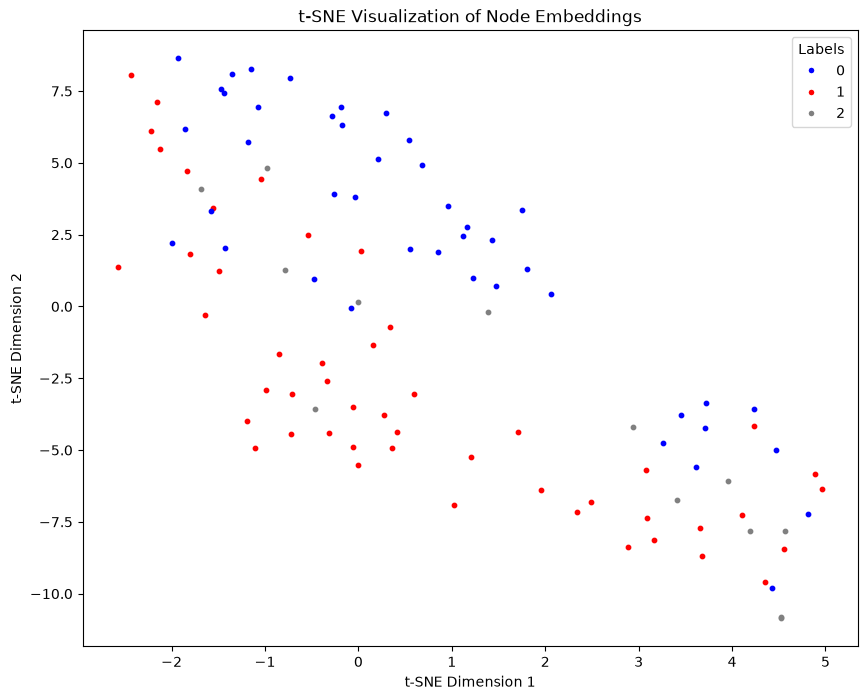

In [60]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assuming 'model' is your trained GNN model
# Assuming 'data' contains your input graph data
# Assuming 'numeric_labels' contains the numeric labels

# Set model to evaluation mode
model.eval()

# Pass the entire dataset through the model to obtain node embeddings
with torch.no_grad():
    mode_out = model(data.x, data.edge_index)
    if isinstance(mode_out, (tuple, list)):
        out = mode_out[0]  # assume the first element contains the embeddings
    else:
        out = mode_out

# Extract embeddings from the output of the GNN model
node_embeddings = out.numpy()

# Reduce dimensionality of embeddings using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(node_embeddings)

# Define colors for different labels
label_colors = {0: 'blue', 1: 'red', 2: 'grey'}

# Plot the embeddings with colored points based on true labels
plt.figure(figsize=(10, 8))
for i in range(len(embeddings_2d)):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], color=label_colors[numeric_labels[i]], s=10)  # Adjust 's' for point size
plt.title('t-SNE Visualization of Node Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=5, label=label) for label, color in label_colors.items()]
plt.legend(handles=handles, title='Labels', loc='best')

plt.show()


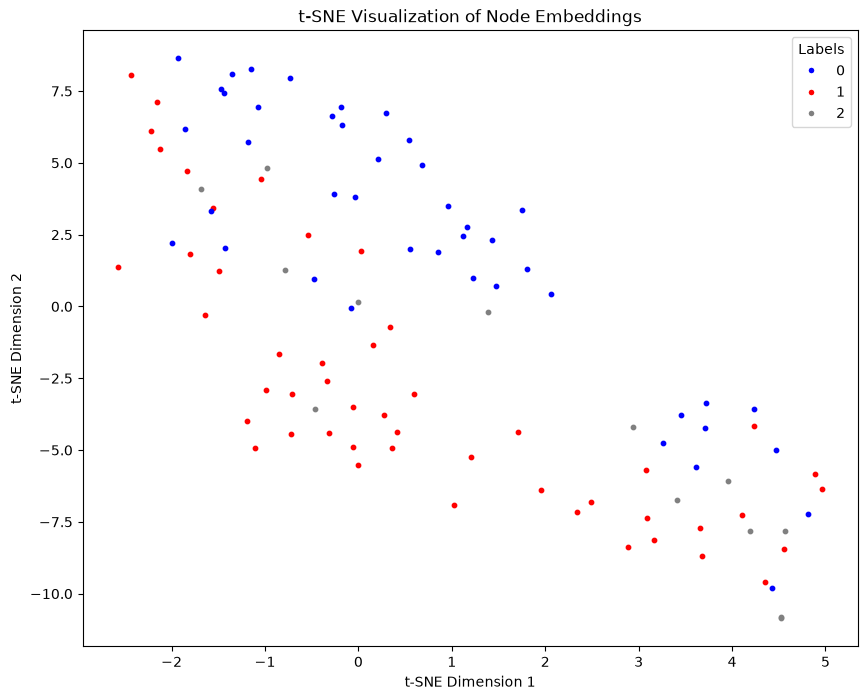

In [61]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assuming 'model' is your trained GNN model
# Assuming 'data' contains your input graph data
# Assuming 'numeric_labels' contains the numeric labels

# Set model to evaluation mode
model.eval()

# Pass the entire dataset through the model to obtain node embeddings
with torch.no_grad():
    model_out = model(data.x, data.edge_index)
    if isinstance(model_out, (tuple, list)):
        out = model_out[0]  # assume the first element contains the embeddings
    else:
        out = model_out

# Extract embeddings from the output of the GNN model
node_embeddings = out.numpy()

# Reduce dimensionality of embeddings using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(node_embeddings)

# Define colors for different labels
label_colors = {0: 'blue', 1: 'red', 2: 'grey'}

# Plot the embeddings with colored points based on true labels
plt.figure(figsize=(10, 8))
for i in range(len(embeddings_2d)):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], color=label_colors[numeric_labels[i]], s=10)  # Adjust 's' for point size
plt.title('t-SNE Visualization of Node Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=5, label=label) for label, color in label_colors.items()]
plt.legend(handles=handles, title='Labels', loc='best')

plt.show()


In [62]:
# Create a simple graph with 5 nodes and labels
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (3, 4)])
labels = np.array(['A', 'B', 'C', 'D', 'E'])  # Node labels

In [63]:
class SimpleGNN_test(torch.nn.Module):
    def __init__(self):
        super(SimpleGNN_test, self).__init__()
        self.conv1 = GCNConv(1, 2)  # Assuming 1-dimensional features, outputting 2-dimensional embeddings

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        return x

# Convert to PyTorch Geometric Data
data = from_networkx(G)
data.x = torch.ones(data.num_nodes, 1)  # Dummy features

# Initialize and apply GNN
model = SimpleGNN_test()
with torch.no_grad():
    gnn_embeddings = model(data).numpy()

print("GNN Embeddings aligned with node order:\n", gnn_embeddings)


GNN Embeddings aligned with node order:
 [[-1.050724    0.14310253]
 [-1.050724    0.14310253]
 [-1.050724    0.14310253]
 [-1.050724    0.14310253]
 [-1.050724    0.14310253]]


In [64]:
node2vec = Node2Vec(G, dimensions=2, walk_length=10, num_walks=5, workers=1)
model = node2vec.fit(window=2)
n2v_embeddings = np.array([model.wv[str(i)] for i in range(len(G))])

print("Node2Vec Embeddings (need alignment):\n", n2v_embeddings)

Generating walks (CPU: 1): 100%|██████████| 5/5 [00:00<00:00, 4693.72it/s]

Node2Vec Embeddings (need alignment):
 [[-0.25236788 -0.1838636 ]
 [-0.02521988  0.0194522 ]
 [ 0.2552317   0.45418254]
 [ 0.3216307   0.44835714]
 [-0.4669228  -0.35699078]]


In [65]:
# For GNN, embeddings are already aligned with labels
print("GNN Labels aligned:", labels)

# For Node2Vec, demonstrate the need for alignment
aligned_labels = np.array([labels[int(node)] for node in model.wv.index_to_key])
print("Node2Vec Labels after alignment:", aligned_labels)

GNN Labels aligned: ['A' 'B' 'C' 'D' 'E']
Node2Vec Labels after alignment: ['B' 'C' 'E' 'D' 'A']


In [66]:
model.wv.index_to_key

['1', '2', '4', '3', '0']